In [1]:
# Importing required libraries

import pandas as pd
import numpy as np

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
# Loading the dataset

df = pd.read_csv(r"C:\Users\ayush kumar gupta\Downloads\Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.shape

(545, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
# Checking missing values

df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
# Checking duplicate rows

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [9]:
# Removing duplicate rows if any

df = df.drop_duplicates()
df.shape

(545, 13)

In [10]:
# Display column names

df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

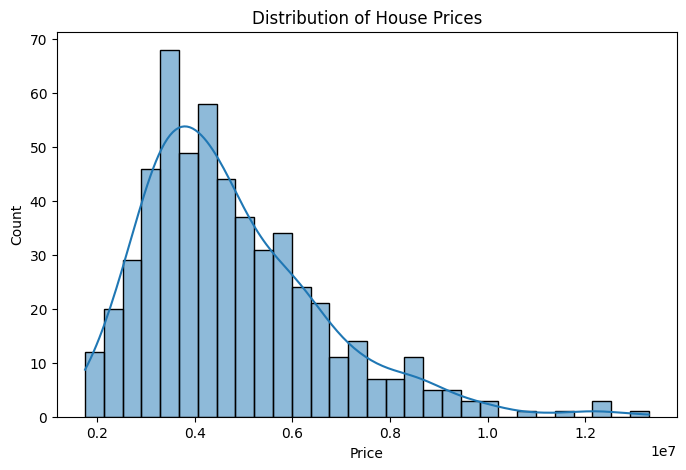

In [30]:
# Plotting the distribution of house prices

plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

In [31]:
### Observation

#The plot shows how house prices are distributed in the dataset.
#This helps us understand whether the prices are evenly distributed or skewed.

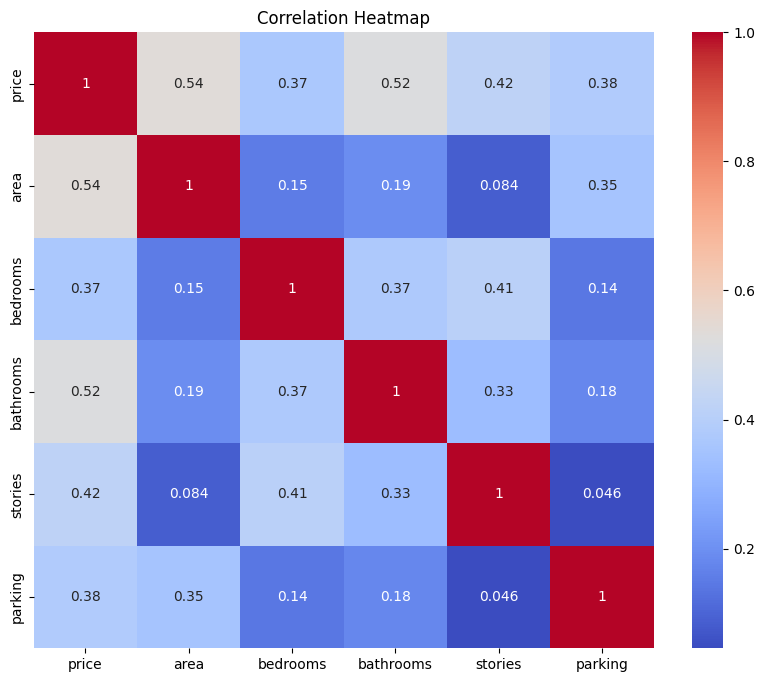

In [11]:
# Correlation between numerical columns

#This helps us understand the relationship between numerical variables.

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [32]:
### Observation

#The heatmap shows the relationship between numerical variables.

#Features with higher correlation to the target variable may have a stronger influence on house price prediction.

In [13]:

#Machine learning models cannot understand text values directly.

#So we will convert categorical columns into numerical values.

# Convert categorical columns into numbers

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.columns:
    
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [33]:
### Why Encoding is Required

#Machine learning algorithms cannot work directly with text values.

#Therefore, categorical columns were converted into numerical values using Label Encoding.

In [14]:
# Checking dataset after encoding

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


In [15]:
# Feature Selection

#In this step, we will select the input features and the target variable.

#The target variable is **price** because we want to predict house prices.

# Selecting input features and target variable

X = df.drop("price", axis=1)

y = df["price"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (545, 12)
Target Shape : (545,)


In [34]:
### Selected Features

#All available house-related features were selected as independent variables because they may contribute to predicting house prices.

#The target variable selected for prediction is **price**.

In [16]:
#We will divide the dataset into training data and testing data.

#- Training Data = 80%
#- Testing Data = 20%

# Splitting the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (436, 12)
Testing Data : (109, 12)


In [17]:
# Creating the model

model = LinearRegression()

In [21]:
# Training the model

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [35]:
# Displaying intercept and coefficients

print("Intercept :", model.intercept_)

print("\nCoefficients")

for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", coef)

Intercept : 293083.0691506723

Coefficients
area : 235.84877178813738
bedrooms : 78574.49238760048
bathrooms : 1097117.2661479586
stories : 406223.16446288314
mainroad : 366824.1923924823
guestroom : 233146.76562655088
basement : 393159.77872584027
hotwaterheating : 687881.3109570172
airconditioning : 785550.5792954292
parking : 225756.5139762815
prefarea : 629901.6608459116
furnishingstatus : -210397.11827155622


In [36]:
### Observation

#The coefficients indicate how each feature affects the predicted house price.

#Positive coefficients increase the predicted price, while negative coefficients decrease it.

In [22]:
# Predicting house prices

y_pred = model.predict(X_test)

y_pred[:5]

array([5203691.70963178, 7257004.02115476, 3062828.59668172,
       4559591.65374424, 3332932.30559782])

In [37]:
# Showing a few predicted values

result.sample(10)

,Actual Price,Predicted Price
49,1820000,3.451822e+06
6,5250000,5.645466e+06
2,3710000,3.062829e+06
84,1890000,2.785343e+06
3,6440000,4.559592e+06
83,6510000,5.386796e+06
67,5110000,3.485106e+06
51,2450000,2.832905e+06
99,5600000,5.943929e+06
102,4900000,3.701491e+06


In [23]:
# Creating comparison table

result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

result.head(10)

,Actual Price,Predicted Price
0,4060000,5.203692e+06
1,6650000,7.257004e+06
2,3710000,3.062829e+06
3,6440000,4.559592e+06
4,2800000,3.332932e+06
5,4900000,3.563081e+06
6,5250000,5.645466e+06
7,4543000,6.413980e+06
8,2450000,2.755832e+06
9,3353000,2.668939e+06


In [24]:
#We will evaluate the model using:

#- Mean Absolute Error (MAE)
#- Mean Squared Error (MSE)
#- Root Mean Squared Error (RMSE)
#- R² Score

# Calculating MAE

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error :", mae)

Mean Absolute Error : 979679.6912959905


In [38]:
### Mean Absolute Error

#MAE represents the average prediction error.

#A lower MAE indicates better model performance.

In [25]:
# Calculating MSE

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error :", mse)

Mean Squared Error : 1771751116594.0347


In [39]:
### Mean Squared Error

#MSE gives more importance to larger errors because the errors are squared.

#Lower MSE values indicate better predictions.

In [26]:
# Calculating RMSE

rmse = np.sqrt(mse)

print("Root Mean Squared Error :", rmse)

Root Mean Squared Error : 1331071.4167895105


In [40]:
### Root Mean Squared Error

#RMSE is the square root of MSE.

#It is easier to understand because it has the same unit as the target variable.

In [27]:
# Calculating R2 Score

r2 = r2_score(y_test, y_pred)

print("R2 Score :", r2)

R2 Score : 0.6494754192267804


In [41]:
### R² Score

#The R² Score tells how well the model explains the variation in house prices.

#A value closer to 1 indicates better prediction performance.

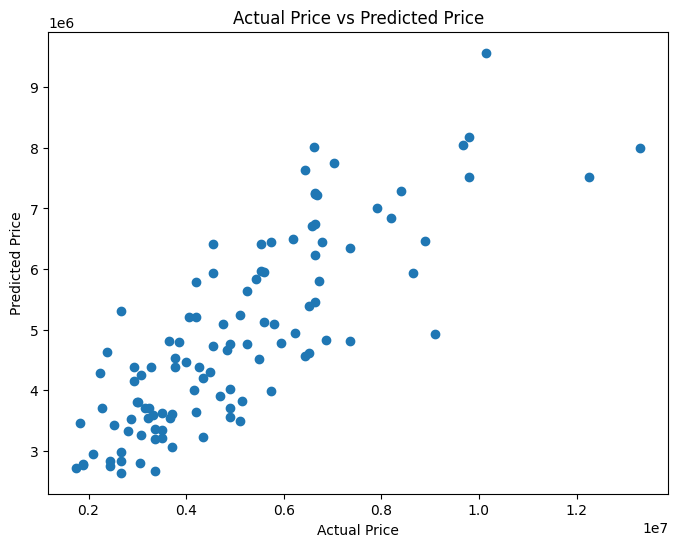

In [28]:
# Actual vs Predicted Plot

# Scatter plot

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")

plt.show()

In [42]:
### Observation

#If most points are close to an imaginary diagonal line, the model predictions are close to the actual values.

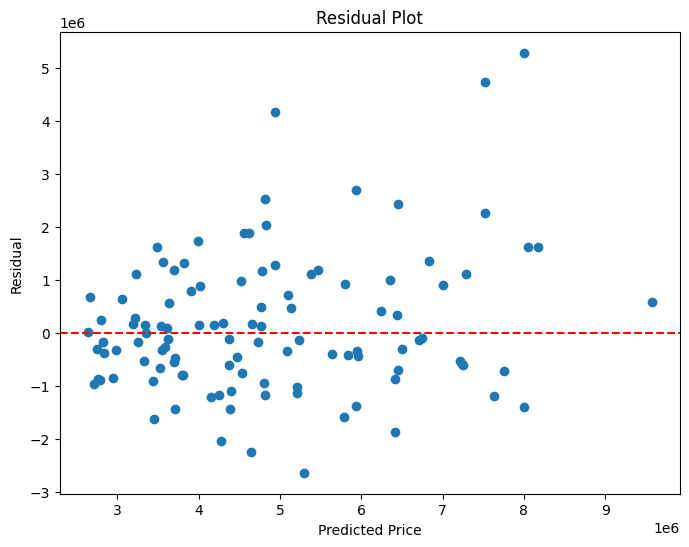

In [29]:
# Residual plot

#Residual means the difference between actual and predicted values.
    
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [43]:
### Observation

#The residual plot helps identify prediction errors.

#Randomly scattered residuals around zero indicate that the Linear Regression model is performing reasonably well.

In [44]:
# Conclusion

#In this project, a Linear Regression model was developed to predict housing prices using different house features.

#The dataset was loaded, explored, and cleaned by checking missing values and duplicate records. Categorical variables were converted into numerical values using Label Encoding. Relevant features were selected, and the data was divided into training and testing sets.

#The Linear Regression model was trained using the training dataset and evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

#Finally, visualizations such as the correlation heatmap, house price distribution, Actual vs Predicted plot, and Residual plot were used to better understand the model's performance.

#Overall, the project provided practical experience in implementing Linear Regression, evaluating its performance, and interpreting the prediction results using Scikit-Learn.